# Olist E-commerce Sales Analysis

**Goal:** Build a beginner-friendly, portfolio-ready sales analysis from raw Olist data to Power BI-ready outputs.

**Important:** Missing values are investigated rather than blindly filled. Payments are analyzed separately from order items to avoid double-counting revenue.


In [3]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)


In [4]:
# 2. Load data
orders = pd.read_csv('data_olist/olist_orders_dataset.csv')
order_items = pd.read_csv('data_olist/olist_order_items_dataset.csv')
products = pd.read_csv('data_olist/olist_products_dataset.csv')
payments = pd.read_csv('data_olist/olist_order_payments_dataset.csv')
customers = pd.read_csv('data_olist/olist_customers_dataset.csv')

## 3. Basic data understanding

In [5]:
datasets = {
    "orders": orders,
    "order_items": order_items,
    "products": products,
    "payments": payments,
    "customers": customers
}

summary = pd.DataFrame([
    {"Table": name, "Rows": df.shape[0], "Columns": df.shape[1]}
    for name, df in datasets.items()
])
display(summary)

for name, df in datasets.items():
    print(f"\n===== {name.upper()} =====")
    display(df.head())


,Table,Rows,Columns
0,orders,99441,8
1,order_items,112650,7
2,products,32951,9
3,payments,103886,5
4,customers,99441,5



===== ORDERS =====


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



===== ORDER_ITEMS =====


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,"1,000.00",30.00,18.00,20.00
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.00,261.00,1.00,371.00,26.00,4.00,26.00
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.00,402.00,4.00,625.00,20.00,17.00,13.00



===== PAYMENTS =====


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45



===== CUSTOMERS =====


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [6]:
# 4. Data types and structure
for name, df in datasets.items():
    print(f"\n===== {name.upper()} =====")
    df.info()



===== ORDERS =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

===== ORDER_ITEMS =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   

In [7]:
# 5. Descriptive statistics
for name, df in datasets.items():
    print(f"\n===== {name.upper()} =====")
    display(df.describe(include="all").T)



===== ORDERS =====


,count,unique,top,freq
order_id,99441,99441,66dea50a8b16d9b4dee7af250b4be1a5,1
customer_id,99441,99441,edb027a75a1449115f6b43211ae02a24,1
order_status,99441,8,delivered,96478
order_purchase_timestamp,99441,98875,2018-08-02 12:05:26,3
order_approved_at,99281,90733,2018-02-27 04:31:10,9
order_delivered_carrier_date,97658,81018,2018-05-09 15:48:00,47
order_delivered_customer_date,96476,95664,2018-05-08 19:36:48,3
order_estimated_delivery_date,99441,459,2017-12-20 00:00:00,522



===== ORDER_ITEMS =====


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,112650,98666,8272b63d03f5f79c56e9e4120aec44ef,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_item_id,"112,650.00",NaN,NaN,NaN,1.20,0.71,1.00,1.00,1.00,1.00,21.00
product_id,112650,32951,aca2eb7d00ea1a7b8ebd4e68314663af,527,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_id,112650,3095,6560211a19b47992c3666cc44a7e94c0,2033,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shipping_limit_date,112650,93318,2017-07-21 18:25:23,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,"112,650.00",NaN,NaN,NaN,120.65,183.63,0.85,39.90,74.99,134.90,"6,735.00"
freight_value,"112,650.00",NaN,NaN,NaN,19.99,15.81,0.00,13.08,16.26,21.15,409.68



===== PRODUCTS =====


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_id,32951,32951,106392145fca363410d287a815be6de4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_category_name,32341,73,cama_mesa_banho,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_name_lenght,"32,341.00",NaN,NaN,NaN,48.48,10.25,5.00,42.00,51.00,57.00,76.00
product_description_lenght,"32,341.00",NaN,NaN,NaN,771.50,635.12,4.00,339.00,595.00,972.00,"3,992.00"
product_photos_qty,"32,341.00",NaN,NaN,NaN,2.19,1.74,1.00,1.00,1.00,3.00,20.00
product_weight_g,"32,949.00",NaN,NaN,NaN,"2,276.47","4,282.04",0.00,300.00,700.00,"1,900.00","40,425.00"
product_length_cm,"32,949.00",NaN,NaN,NaN,30.82,16.91,7.00,18.00,25.00,38.00,105.00
product_height_cm,"32,949.00",NaN,NaN,NaN,16.94,13.64,2.00,8.00,13.00,21.00,105.00
product_width_cm,"32,949.00",NaN,NaN,NaN,23.20,12.08,6.00,15.00,20.00,30.00,118.00



===== PAYMENTS =====


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,103886,99440,fa65dad1b0e818e3ccc5cb0e39231352,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_sequential,"103,886.00",NaN,NaN,NaN,1.09,0.71,1.00,1.00,1.00,1.00,29.00
payment_type,103886,5,credit_card,76795,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_installments,"103,886.00",NaN,NaN,NaN,2.85,2.69,0.00,1.00,1.00,4.00,24.00
payment_value,"103,886.00",NaN,NaN,NaN,154.10,217.49,0.00,56.79,100.00,171.84,"13,664.08"



===== CUSTOMERS =====


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,99441,99441,274fa6071e5e17fe303b9748641082c8,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_unique_id,99441,96096,8d50f5eadf50201ccdcedfb9e2ac8455,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_zip_code_prefix,"99,441.00",NaN,NaN,NaN,"35,137.47","29,797.94","1,003.00","11,347.00","24,416.00","58,900.00","99,990.00"
customer_city,99441,4119,sao paulo,15540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_state,99441,27,SP,41746,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6. Missing values


- Missing delivery dates can be legitimate when an order was not delivered.
- Missing product attributes are not necessarily needed for this sales project.
- Critical sales fields such as price/payment value must be checked before use.


In [8]:
def missing_summary(df):
    return pd.DataFrame({
        "missing_values": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2)
    }).sort_values("missing_pct", ascending=False)

for name, df in datasets.items():
    print(f"\n===== {name.upper()} =====")
    display(missing_summary(df))



===== ORDERS =====


,missing_values,missing_pct
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
order_approved_at,160,0.16
order_id,0,0.00
order_purchase_timestamp,0,0.00
order_status,0,0.00
customer_id,0,0.00
order_estimated_delivery_date,0,0.00



===== ORDER_ITEMS =====


,missing_values,missing_pct
order_id,0,0.00
order_item_id,0,0.00
product_id,0,0.00
seller_id,0,0.00
shipping_limit_date,0,0.00
price,0,0.00
freight_value,0,0.00



===== PRODUCTS =====


,missing_values,missing_pct
product_category_name,610,1.85
product_description_lenght,610,1.85
product_name_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_height_cm,2,0.01
product_length_cm,2,0.01
product_width_cm,2,0.01
product_id,0,0.00



===== PAYMENTS =====


,missing_values,missing_pct
order_id,0,0.00
payment_sequential,0,0.00
payment_type,0,0.00
payment_installments,0,0.00
payment_value,0,0.00



===== CUSTOMERS =====


,missing_values,missing_pct
customer_id,0,0.00
customer_unique_id,0,0.00
customer_zip_code_prefix,0,0.00
customer_city,0,0.00
customer_state,0,0.00


### Investigate missing order dates by order status

In [9]:
missing_delivery = (
    orders.groupby("order_status")[
        ["order_approved_at",
         "order_delivered_carrier_date",
         "order_delivered_customer_date"]
    ].apply(lambda x: x.isna().sum())
)
display(missing_delivery)


,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
order_status,,,
approved,0,2,2
canceled,141,550,619
created,5,5,5
delivered,14,2,8
invoiced,0,314,314
processing,0,301,301
shipped,0,0,1107
unavailable,0,609,609


### Data Quality Insight

- The orders table has 2.98% missing values in `order_delivered_customer_date` and 1.79% in `order_delivered_carrier_date`.
- Missing delivery dates are concentrated in non-delivered statuses such as canceled, unavailable, processing and shipped orders.
- Among delivered orders, only 8 customer-delivery dates and 2 carrier dates are missing, so missing delivery information has very limited impact on the completed-sales analysis.
- Product category information is missing for 610 products (1.85%), so these records were explicitly labeled as `Unknown` rather than removed.

### Decision

Delivery-date missing values were retained because they can represent legitimate order statuses. Product categories were labeled `Unknown` because category information is required for category-level analysis.

### Handling only what is appropriate

In [10]:
# Product category is required for category analysis, so unknown categories are labeled explicitly.
products["product_category_name"] = (
    products["product_category_name"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
)

# We intentionally keep delivery-date NaNs.
# We do not fill price, freight or payment values without evidence that they are missing/incorrect.


## 7. Duplicate checks

In [11]:
for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicate rows")


orders: 0 duplicate rows
order_items: 0 duplicate rows
products: 0 duplicate rows
payments: 0 duplicate rows
customers: 0 duplicate rows


### Data Quality Insight

- No exact duplicate rows were found in any of the five tables.
- This indicates that there are no exact row-level duplicates that need to be removed before analysis.
- However, repeated `order_id` values in the order-items and payments tables are legitimate because one order can contain multiple items or payment records.

### Decision

No rows were removed based on duplicate checks.

## 8. Key and grain checks

In [12]:
print("Unique orders:", orders["order_id"].nunique(), "/", len(orders))
print("Unique customers:", customers["customer_id"].nunique(), "/", len(customers))
print("Unique products:", products["product_id"].nunique(), "/", len(products))

print("\nOrders with multiple item rows:")
display(order_items["order_id"].value_counts().head(10))

print("\nOrders with multiple payment rows:")
display(payments["order_id"].value_counts().head(10))


Unique orders: 99441 / 99441
Unique customers: 99441 / 99441
Unique products: 32951 / 32951

Orders with multiple item rows:


order_id
8272b63d03f5f79c56e9e4120aec44ef    21
1b15974a0141d54e36626dca3fdc731a    20
ab14fdcfbe524636d65ee38360e22ce8    20
9ef13efd6949e4573a18964dd1bbe7f5    15
428a2f660dc84138d969ccd69a0ab6d5    15
9bdc4d4c71aa1de4606060929dee888c    14
73c8ab38f07dc94389065f7eba4f297a    14
37ee401157a3a0b28c9c6d0ed8c3b24b    13
af822dacd6f5cff7376413c03a388bb7    12
3a213fcdfe7d98be74ea0dc05a8b31ae    12
Name: count, dtype: int64


Orders with multiple payment rows:


order_id
fa65dad1b0e818e3ccc5cb0e39231352    29
ccf804e764ed5650cd8759557269dc13    26
285c2e15bebd4ac83635ccc563dc71f4    22
895ab968e7bb0d5659d16cd74cd1650c    21
fedcd9f7ccdc8cba3a18defedd1a5547    19
ee9ca989fc93ba09a6eddc250ce01742    19
21577126c19bf11a0b91592e5844ba78    15
4bfcba9e084f46c8e3cb49b0fa6e6159    15
4689b1816de42507a7d63a4617383c59    14
3c58bffb70dcf45f12bdf66a3c215905    14
Name: count, dtype: int64

## 9. Date cleaning and sales period

In [13]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

print("First purchase:", orders["order_purchase_timestamp"].min())
print("Last purchase:", orders["order_purchase_timestamp"].max())


First purchase: 2016-09-04 21:15:19
Last purchase: 2018-10-17 17:30:18


## 10. Numeric validation

In [14]:
checks = {
    "price <= 0": (order_items["price"] <= 0).sum(),
    "freight < 0": (order_items["freight_value"] < 0).sum(),
    "payment <= 0": (payments["payment_value"] <= 0).sum(),
    "installments < 1": (payments["payment_installments"] < 1).sum()
}
display(pd.DataFrame(list(checks.items()), columns=["Check", "Count"]))


,Check,Count
0,price <= 0,0
1,freight < 0,0
2,payment <= 0,9
3,installments < 1,2


### Data Quality Insight

- No order-item records have a price less than or equal to zero.
- No records have negative freight values.
- Nine payment records have payment values less than or equal to zero.
- Two payment records have fewer than one installment.

### Decision

The sales analysis uses product price and freight from the order-items table, where no invalid price or negative freight values were found. The small number of payment anomalies should be monitored but do not affect the product-sales analysis because payments are analyzed separately.

## 11. Order-status analysis

,order_status,orders,percentage
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


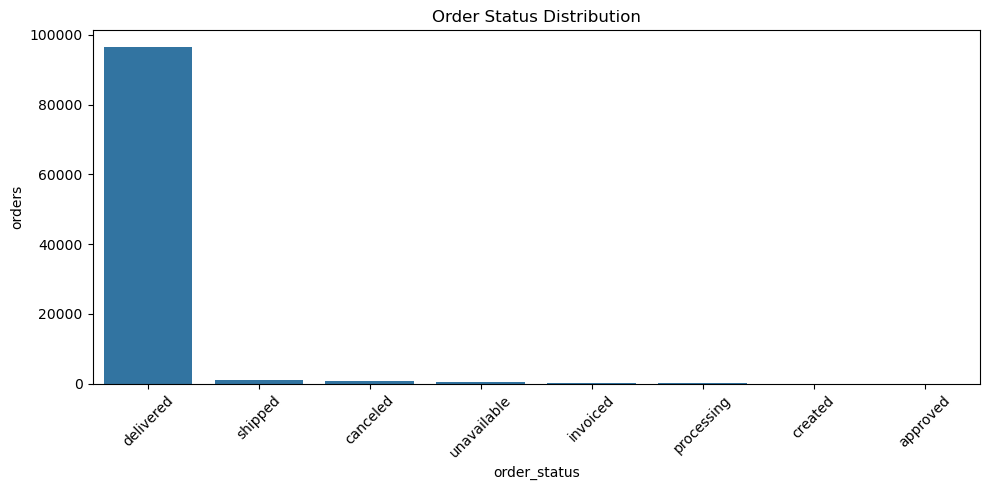

In [15]:
order_status = (
    orders["order_status"]
    .value_counts()
    .rename_axis("order_status")
    .reset_index(name="orders")
)
order_status["percentage"] = order_status["orders"] / order_status["orders"].sum() * 100
display(order_status)

plt.figure(figsize=(10,5))
sns.barplot(data=order_status, x="order_status", y="orders")
plt.title("Order Status Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Business Insight

- The dataset contains 99,441 orders, of which 96,478 (97.02%) were successfully delivered.
- Shipped orders account for 1,107 orders (1.11%), while canceled and unavailable orders account for 625 (0.63%) and 609 (0.61%) orders respectively.
- Therefore, the vast majority of orders successfully reached the delivered stage.
- The relatively small share of canceled and unavailable orders indicates that order fulfillment was generally successful during the analyzed period.

### Business Implication

The business should maintain the existing fulfillment performance while investigating the reasons behind canceled and unavailable orders to identify opportunities for further reducing unsuccessful orders.

## 12. Building the completed-sales base

For the core sales-performance analysis, completed sales are orders with `order_status == 'delivered'`.

In [16]:
completed_orders = orders.loc[orders["order_status"].eq("delivered")].copy()

sales = completed_orders.merge(
    order_items,
    on="order_id",
    how="inner",
    validate="one_to_many"
)

sales = sales.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left",
    validate="many_to_one"
)

sales = sales.merge(
    customers[["customer_id", "customer_city", "customer_state"]],
    on="customer_id",
    how="left",
    validate="many_to_one"
)

sales["product_category_name"] = sales["product_category_name"].fillna("Unknown")

print("Completed orders:", completed_orders["order_id"].nunique())
print("Sales rows:", len(sales))


Completed orders: 96478
Sales rows: 110197


### Data Preparation Insight

- 96,478 delivered orders were selected as the completed-sales population.
- These orders produced 110,197 order-item records.
- The difference between orders and sales rows occurs because a single order can contain multiple products.
- Therefore, order-level metrics should use distinct `order_id`, while unit-level metrics can use the number of order-item rows.

### Analytical Decision

The core sales analysis is based on delivered orders to focus on completed sales performance.

## 13. Creating analysis fields

In [17]:
sales["year"] = sales["order_purchase_timestamp"].dt.year
sales["month"] = sales["order_purchase_timestamp"].dt.month
sales["year_month"] = sales["order_purchase_timestamp"].dt.to_period("M").astype(str)
sales["day_of_week"] = sales["order_purchase_timestamp"].dt.day_name()


## 14. Overall sales KPIs

In [18]:
total_revenue = sales["price"].sum()
total_orders = sales["order_id"].nunique()
total_units = len(sales)
total_freight = sales["freight_value"].sum()
aov = total_revenue / total_orders

sales_kpis = pd.DataFrame({
    "Metric": ["Total Revenue", "Total Orders", "Total Units Sold", "AOV", "Total Freight"],
    "Value": [total_revenue, total_orders, total_units, aov, total_freight]
})
display(sales_kpis)


,Metric,Value
0,Total Revenue,"13,221,498.11"
1,Total Orders,"96,478.00"
2,Total Units Sold,"110,197.00"
3,AOV,137.04
4,Total Freight,"2,198,275.64"


### Business Insight

- The completed-sales analysis generated $13.22M in product revenue from 96,478 delivered orders.
- A total of 110,197 product units were sold, resulting in an Average Order Value (AOV) of $137.04.
- Total freight value was $2.20M, equivalent to approximately 16.63% of product revenue.
- The difference between 96,478 orders and 110,197 units shows that customers frequently purchased multiple items within an order.

### Business Implication

The business has significant sales volume, but freight represents a meaningful cost component. Therefore, sales performance should be evaluated together with shipping costs rather than looking at product revenue alone.

## 15. Monthly sales and growth

In [19]:
monthly_sales = (
    sales.groupby("year_month", as_index=False)
    .agg(
        revenue=("price", "sum"),
        orders=("order_id", "nunique"),
        units=("order_item_id", "count"),
        freight=("freight_value", "sum")
    )
)
monthly_sales["aov"] = monthly_sales["revenue"] / monthly_sales["orders"]
monthly_sales["revenue_mom_growth_pct"] = monthly_sales["revenue"].pct_change() * 100
monthly_sales["orders_mom_growth_pct"] = monthly_sales["orders"].pct_change() * 100
display(monthly_sales)


,year_month,revenue,orders,units,freight,aov,revenue_mom_growth_pct,orders_mom_growth_pct
0,2016-09,134.97,1,3,8.49,134.97,NaN,NaN
1,2016-10,"40,325.11",265,313,"6,165.55",152.17,"29,777.09","26,400.00"
2,2016-12,10.90,1,1,8.72,10.90,-99.97,-99.62
3,2017-01,"111,798.36",750,913,"15,684.01",149.06,"1,025,573.03","74,900.00"
4,2017-02,"234,223.40",1653,1858,"37,015.92",141.70,109.51,120.40
5,2017-03,"359,198.85",2546,2897,"55,132.10",141.08,53.36,54.02
6,2017-04,"340,669.68",2303,2569,"50,142.72",147.92,-5.16,-9.54
7,2017-05,"489,338.25",3546,4004,"77,513.15",138.00,43.64,53.97
8,2017-06,"421,923.37",3135,3489,"68,127.00",134.58,-13.78,-11.59
9,2017-07,"481,604.52",3872,4416,"84,694.56",124.38,14.15,23.51


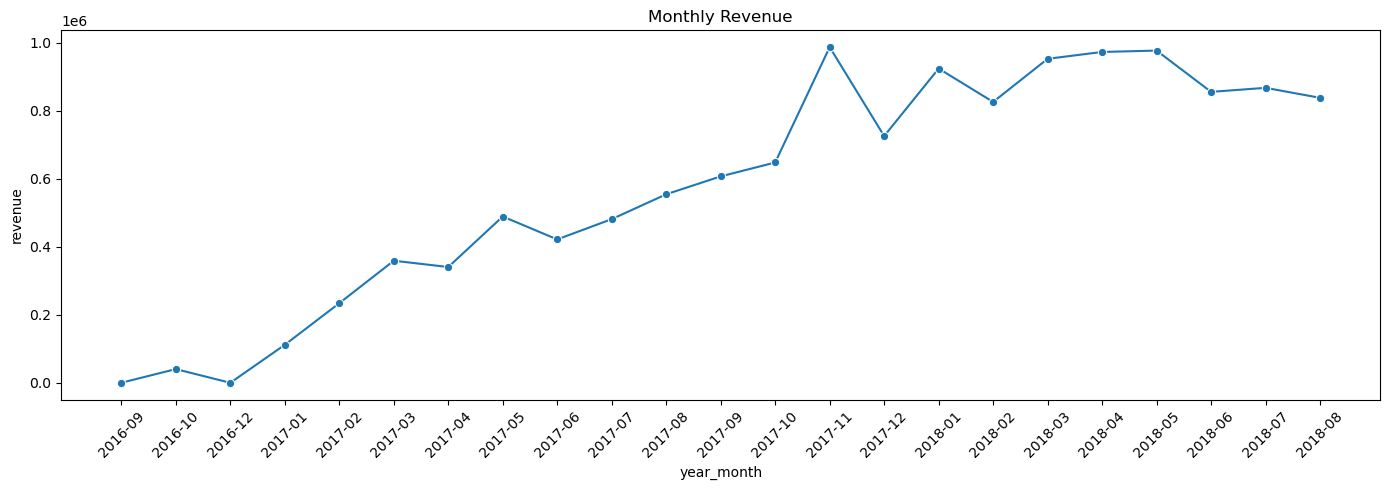

In [20]:
plt.figure(figsize=(14,5))
sns.lineplot(data=monthly_sales, x="year_month", y="revenue", marker="o")
plt.title("Monthly Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Business Insight

- November 2017 was the strongest month in the completed-sales analysis, generating $987,765.37 in product revenue from 7,289 orders.
- Revenue increased by 52.37% compared with October 2017, while order volume increased by 62.77%.
- Because order growth was higher than revenue growth, the November sales peak was primarily driven by increased order volume rather than a major increase in average order value.
- November recorded an AOV of $135.51, which was slightly below October's $144.76.
- December 2017 revenue declined by 26.50% from November, accompanied by a 24.37% decline in orders.

### Business Implication

The November sales peak should be investigated to understand the factors behind the strong increase in order volume. The business can use successful strategies from high-volume periods when planning future campaigns and promotions.

## 16. Product performance

In [21]:
product_sales = (
    sales.groupby("product_id", as_index=False)
    .agg(
        revenue=("price", "sum"),
        units_sold=("order_item_id", "count"),
        orders=("order_id", "nunique")
    )
)
display(product_sales.sort_values("revenue", ascending=False).head(10))


,product_id,revenue,units_sold,orders
23546,bb50f2e236e5eea0100680137654686c,"63,560.00",194,186
13749,6cdd53843498f92890544667809f1595,"53,652.30",153,148
26997,d6160fb7873f184099d9bc95e30376af,"45,949.35",33,33
26436,d1c427060a0f73f6b889a5c7c61f2ac4,"45,620.56",332,313
19290,99a4788cb24856965c36a24e339b6058,"42,049.66",477,456
7881,3dd2a17168ec895c781a9191c1e95ad7,"40,782.80",272,253
4892,25c38557cf793876c5abdd5931f922db,"38,907.32",38,38
12074,5f504b3a1c75b73d6151be81eb05bdc9,"37,733.90",63,63
10616,53b36df67ebb7c41585e8d54d6772e08,"37,454.63",321,304
21617,aca2eb7d00ea1a7b8ebd4e68314663af,"37,104.30",520,425


### Business Insight

- The highest-revenue individual product generated $63,560.00 in product revenue from 194 units across 186 orders.
- The top 10 products generated approximately $442.82K in revenue, representing approximately 3.35% of total product revenue.
- Revenue among the top products is not driven by unit volume alone. For example, the tenth-ranked product sold 520 units, while the third-ranked product generated higher revenue with only 33 units.
- This indicates that product price and sales volume both play important roles in determining product revenue.

### Business Implication

The business should distinguish between high-volume products and high-value products when making inventory and promotional decisions. Both groups can be strategically important for different reasons.

## 17. Category performance

In [22]:
category_sales = (
    sales.groupby("product_category_name", as_index=False)
    .agg(
        revenue=("price", "sum"),
        units_sold=("order_item_id", "count"),
        orders=("order_id", "nunique")
    )
)
category_sales["aov"] = category_sales["revenue"] / category_sales["orders"]
category_sales["revenue_share_pct"] = category_sales["revenue"] / category_sales["revenue"].sum() * 100
display(category_sales.sort_values("revenue", ascending=False).head(10))


,product_category_name,revenue,units_sold,orders,aov,revenue_share_pct
12,beleza_saude,"1,233,131.72",9465,8647,142.61,9.33
67,relogios_presentes,"1,166,176.98",5859,5495,212.23,8.82
14,cama_mesa_banho,"1,023,434.76",10953,9272,110.38,7.74
33,esporte_lazer,"954,852.55",8431,7530,126.81,7.22
45,informatica_acessorios,"888,724.61",7644,6530,136.10,6.72
55,moveis_decoracao,"711,927.69",8160,6307,112.88,5.38
73,utilidades_domesticas,"615,628.69",6795,5743,107.20,4.66
27,cool_stuff,"610,204.10",3718,3559,171.45,4.62
9,automotivo,"578,966.65",4140,3810,151.96,4.38
13,brinquedos,"471,286.48",4030,3804,123.89,3.56


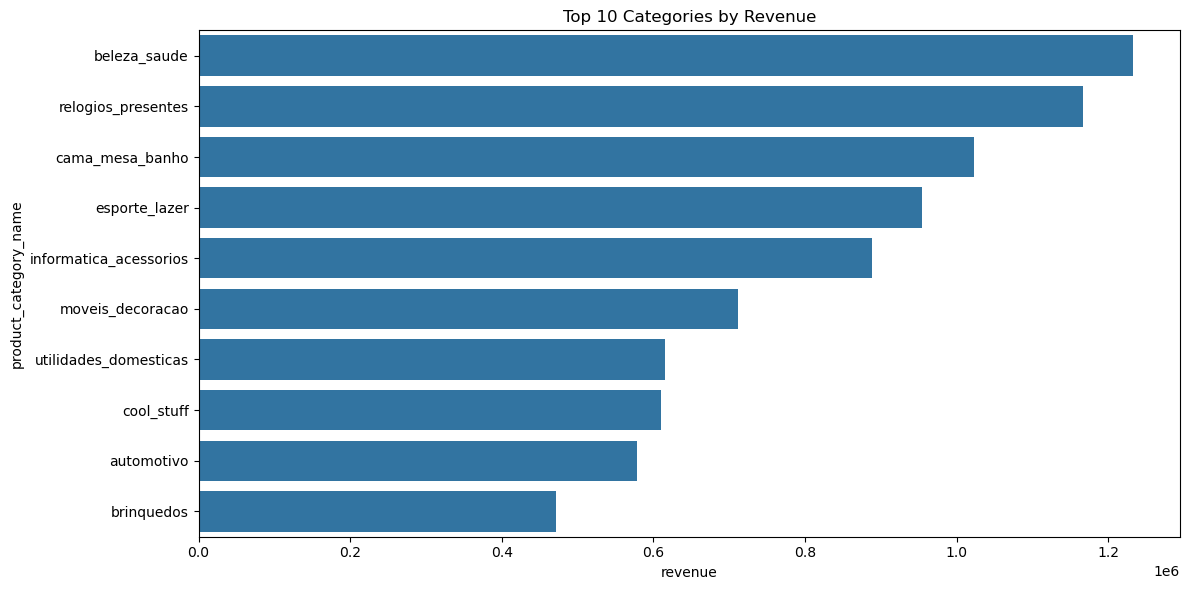

In [23]:
top_categories = category_sales.nlargest(10, "revenue")
plt.figure(figsize=(12,6))
sns.barplot(data=top_categories, x="revenue", y="product_category_name")
plt.title("Top 10 Categories by Revenue")
plt.tight_layout()
plt.show()


### Business Insight

- Health & Beauty (`beleza_saude`) is the highest-revenue category, generating $1.23M and contributing 9.33% of total product revenue.
- Watches & Gifts (`relogios_presentes`) generated $1.17M, followed by Bed & Bath Table (`cama_mesa_banho`) at $1.02M.
- The top five categories generated approximately 39.83% of total product revenue.
- Health & Beauty also recorded 9,465 units across 8,647 orders, while Bed & Bath Table sold the highest number of units among the top five categories at 10,953.
- Watches & Gifts had the highest AOV among the top five categories at $212.23.

### Business Implication

The strongest categories represent important revenue drivers and should receive appropriate inventory and marketing attention. The difference between category revenue, units and AOV also shows why category performance should not be evaluated using revenue alone.

## 18. Geographic performance

In [24]:
state_sales = (
    sales.groupby("customer_state", as_index=False)
    .agg(
        revenue=("price", "sum"),
        orders=("order_id", "nunique"),
        units_sold=("order_item_id", "count")
    )
)
state_sales["aov"] = state_sales["revenue"] / state_sales["orders"]
display(state_sales.sort_values("revenue", ascending=False).head(10))


,customer_state,revenue,orders,units_sold,aov
25,SP,"5,067,633.16",40501,46448,125.12
18,RJ,"1,759,651.13",12350,14143,142.48
10,MG,"1,552,481.83",11354,12916,136.73
22,RS,"728,897.47",5345,6134,136.37
17,PR,"666,063.51",4923,5649,135.30
23,SC,"507,012.13",3546,4097,142.98
4,BA,"493,584.14",3256,3683,151.59
6,DF,"296,498.41",2080,2355,142.55
8,GO,"282,836.70",1957,2277,144.53
7,ES,"268,643.45",1995,2225,134.66


### Business Insight

- São Paulo (SP) is the strongest geographic market, generating $5.07M in product revenue from 40,501 orders.
- SP alone contributes approximately 38.33% of total product revenue.
- Rio de Janeiro (RJ) generated $1.76M, while Minas Gerais (MG) generated $1.55M.
- The top three states—SP, RJ and MG—collectively generated approximately $8.38M, representing about 63.4% of total product revenue.
- Although SP generates the highest revenue, its AOV of $125.12 is lower than several other major states, indicating that its dominance is primarily driven by order volume.

### Business Implication

São Paulo should remain a key market for retention and marketing investment. At the same time, high-AOV states can be investigated for opportunities to increase customer acquisition and revenue.

## 19. Payment analysis

Payments remain separate from the sales item table to prevent double-counting.

In [25]:
payment_analysis = (
    payments.groupby("payment_type", as_index=False)
    .agg(
        payment_value=("payment_value", "sum"),
        payment_records=("payment_type", "size"),
        orders=("order_id", "nunique")
    )
)
payment_analysis["payment_share_pct"] = payment_analysis["payment_value"] / payment_analysis["payment_value"].sum() * 100
display(payment_analysis)


,payment_type,payment_value,payment_records,orders,payment_share_pct
0,boleto,"2,869,361.27",19784,19784,17.92
1,credit_card,"12,542,084.19",76795,76505,78.34
2,debit_card,"217,989.79",1529,1528,1.36
3,not_defined,0.00,3,3,0.00
4,voucher,"379,436.87",5775,3866,2.37


### Business Insight

- Credit card is the dominant payment method, accounting for $12.54M or 78.34% of total payment value.
- Boleto is the second-largest payment method, contributing $2.87M or 17.92%.
- Together, credit card and boleto account for approximately 96.26% of total payment value.
- Debit cards and vouchers represent much smaller shares of payment value.
- Credit-card transactions also represent the largest number of payment records, with 76,795 records.

### Business Implication

Credit-card and boleto payment experiences are particularly important for the business because together they account for more than 96% of payment value. Payment reliability and customer experience for these methods should therefore be prioritized.

## 20. Freight analysis

In [26]:
category_freight = (
    sales.groupby("product_category_name", as_index=False)
    .agg(
        revenue=("price", "sum"),
        freight=("freight_value", "sum")
    )
)
category_freight["freight_to_revenue_pct"] = category_freight["freight"] / category_freight["revenue"] * 100
display(category_freight.sort_values("freight_to_revenue_pct", ascending=False).head(10))


,product_category_name,revenue,freight,freight_to_revenue_pct
16,casa_conforto_2,760.27,410.31,53.97
42,flores,"1,110.04",488.87,44.04
53,moveis_colchao_e_estofado,"4,323.38","1,581.37",36.58
7,artigos_de_natal,"8,737.84","3,190.91",36.52
43,fraldas_higiene,"1,500.79",545.40,36.34
18,cds_dvds_musicais,730.00,224.99,30.82
69,sinalizacao_e_seguranca,"21,315.05","6,477.54",30.39
31,eletronicos,"155,043.93","45,679.16",29.46
3,alimentos_bebidas,"14,942.88","4,394.89",29.41
28,dvds_blu_ray,"4,542.59","1,227.25",27.02


### Business Insight

- Freight costs vary significantly across product categories.
- `casa_conforto_2` has the highest freight-to-revenue ratio at 53.97%, meaning freight is equivalent to more than half of its product revenue.
- `flores` has the second-highest ratio at 44.04%.
- `moveis_colchao_e_estofado` and `artigos_de_natal` also have freight-to-revenue ratios above 36%.
- Some categories have very high ratios but relatively small revenue bases. Therefore, freight ratio should be evaluated together with absolute revenue and freight value.
- `eletronicos` is particularly noteworthy because it combines a relatively high freight-to-revenue ratio of 29.46% with $155.04K in product revenue and $45.68K in freight.

### Business Implication

Categories with high freight-to-revenue ratios should be investigated for shipping, packaging and fulfillment optimization. Categories with both high revenue and high freight costs should receive particular attention because improvements can have a larger financial impact.

## 21. Final data-quality report

In [27]:
def quality_report(df, name):
    return pd.DataFrame({
        "table": [name] * len(df.columns),
        "column": df.columns,
        "dtype": [str(df[c].dtype) for c in df.columns],
        "missing_values": [df[c].isna().sum() for c in df.columns],
        "missing_pct": [df[c].isna().mean() * 100 for c in df.columns],
        "unique_values": [df[c].nunique(dropna=True) for c in df.columns]
    })

quality = pd.concat(
    [quality_report(df, name) for name, df in datasets.items()],
    ignore_index=True
)
display(quality)


,table,column,dtype,missing_values,missing_pct,unique_values
0,orders,order_id,object,0,0.00,99441
1,orders,customer_id,object,0,0.00,99441
2,orders,order_status,object,0,0.00,8
3,orders,order_purchase_timestamp,datetime64[ns],0,0.00,98875
4,orders,order_approved_at,datetime64[ns],160,0.16,90733
5,orders,order_delivered_carrier_date,datetime64[ns],1783,1.79,81018
6,orders,order_delivered_customer_date,datetime64[ns],2965,2.98,95664
7,orders,order_estimated_delivery_date,datetime64[ns],0,0.00,459
8,order_items,order_id,object,0,0.00,98666
9,order_items,order_item_id,int64,0,0.00,21


## 22. Export Power BI-ready tables

In [28]:
import os
os.makedirs("../output", exist_ok=True)

outputs = {
    "sales_base.csv": sales,
    "sales_kpis.csv": sales_kpis,
    "monthly_sales.csv": monthly_sales,
    "product_sales.csv": product_sales,
    "category_sales.csv": category_sales,
    "state_sales.csv": state_sales,
    "payment_analysis.csv": payment_analysis,
    "order_status.csv": order_status,
    "category_freight.csv": category_freight,
    "data_quality_report.csv": quality
}

for filename, df in outputs.items():
    df.to_csv(f"../output/{filename}", index=False)

print("All analysis tables exported successfully.")


All analysis tables exported successfully.


# 23. Business questions this project answers

- What is total revenue, orders, units and AOV?
- How is revenue changing month by month?
- Which months perform best/worst?
- Which products generate the most revenue?
- Which categories contribute most to revenue?
- Which states generate the most revenue?
- Which payment methods are most used?
- How significant is freight relative to product revenue?
- What does order status tell us about completed and non-completed orders?




# Final Business Insights & Recommendations

## Key Business Findings

### 1. Strong Order Fulfillment

The dataset contains 99,441 orders, of which 96,478 (97.02%) were successfully delivered. This indicates a strong overall fulfillment rate.

### 2. Strong Sales Performance

Completed delivered orders generated $13.22M in product revenue across 96,478 orders and 110,197 units. The average order value was $137.04.

### 3. Freight Is a Significant Cost Component

Total freight amounted to $2.20M, representing approximately 16.63% of product revenue. Therefore, sales performance should be evaluated together with shipping costs.

### 4. November 2017 Was the Strongest Sales Month

November 2017 generated $987,765.37 in product revenue from 7,289 orders. Revenue increased 52.37% month-over-month, while orders increased 62.77%, indicating that the peak was primarily driven by higher order volume.

### 5. Revenue Is Concentrated Among Major Categories

Health & Beauty was the highest-revenue category at $1.23M, contributing 9.33% of total product revenue. The top five categories collectively contributed approximately 39.83% of total revenue.

### 6. Product Revenue Is Not Driven by Volume Alone

The top 10 individual products generated approximately $442.82K, or 3.35% of total product revenue. Some high-revenue products achieved their ranking through high unit volume, while others generated high revenue with considerably fewer units, demonstrating the importance of both price and volume.

### 7. Sales Are Geographically Concentrated

São Paulo generated $5.07M in product revenue and accounted for approximately 38.33% of total revenue. São Paulo, Rio de Janeiro and Minas Gerais together contributed approximately 63.4% of total product revenue.

### 8. Credit Card Dominates Payment Value

Credit card payments represented $12.54M or 78.34% of total payment value. Credit card and boleto together accounted for approximately 96.26% of payment value.

### 9. Freight Impact Varies by Category

Some categories have extremely high freight-to-revenue ratios. `casa_conforto_2` had the highest ratio at 53.97%, while `eletronicos` had a 29.46% ratio alongside $155.04K in product revenue, making it a more financially significant freight-optimization opportunity.

## Business Recommendations

1. Maintain the strong fulfillment performance while investigating the causes of canceled and unavailable orders.

2. Investigate the factors behind the November 2017 sales peak and identify strategies that could be replicated during future high-demand periods.

3. Prioritize inventory and marketing attention for major revenue-generating categories such as Health & Beauty, Watches & Gifts and Bed & Bath Table.

4. Evaluate high-revenue products separately from high-volume products because revenue performance is influenced by both selling price and unit volume.

5. Continue focusing on São Paulo as a major market while exploring growth opportunities in other high-AOV states.

6. Prioritize reliability and customer experience for credit-card and boleto payments because they account for approximately 96.26% of payment value.

7. Investigate categories with high freight-to-revenue ratios, particularly where the category also generates substantial revenue.

8. Use freight-to-revenue analysis alongside product revenue when evaluating category performance so that high sales do not hide significant shipping costs.